# Trabalho Parcial - Ciências de Dados e Inteligência Artifical:classificação de diabetes


## Parte 1 do Código: Bibliotecas

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, ConfusionMatrixDisplay, classification_report
)
from sklearn.base import clone
import joblib

RANDOM_STATE = 42
ARQUIVO = Path("diabetes.csv")

## Parte 2 do Código: Leitura dos dados

In [ ]:
if not ARQUIVO.exists():
    raise FileNotFoundError(
        f"Não encontrei {ARQUIVO.resolve()}. Baixe o CSV do Kaggle, "
        "coloque-o na pasta deste notebook e execute novamente."
    )

df = pd.read_csv(ARQUIVO)
print("Dimensões (linhas, colunas):", df.shape)
display(df.head())
print("\nTipos e valores não nulos:")
df.info()
print("\nNomes das colunas:", df.columns.tolist())

Dimensões (linhas, colunas): (403, 19)


,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0



Tipos e valores não nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        403 non-null    int64  
 1   chol      402 non-null    float64
 2   stab.glu  403 non-null    int64  
 3   hdl       402 non-null    float64
 4   ratio     402 non-null    float64
 5   glyhb     390 non-null    float64
 6   location  403 non-null    object 
 7   age       403 non-null    int64  
 8   gender    403 non-null    object 
 9   height    398 non-null    float64
 10  weight    402 non-null    float64
 11  frame     391 non-null    object 
 12  bp.1s     398 non-null    float64
 13  bp.1d     398 non-null    float64
 14  bp.2s     141 non-null    float64
 15  bp.2d     141 non-null    float64
 16  waist     401 non-null    float64
 17  hip       401 non-null    float64
 18  time.ppn  400 non-null    float64
dtypes: float64(13), int64(3), object(3)
memory 

In [ ]:
if 'glyhb' in df.columns:
    print("Criando coluna 'diabetes' com base em 'glyhb' >= 7.0...")

    df['diabetes'] = np.where(
        df['glyhb'].notna(),
        (df['glyhb'] >= 7.0).astype(int),
        np.nan
    )

    # Remove registros que não possuem informação suficiente
    # para determinar a classe de diabetes.
    df = df.dropna(subset=['diabetes']).copy()

    df['diabetes'] = df['diabetes'].astype(int)

TARGET = 'diabetes'

if TARGET not in df.columns:
    raise ValueError(f"A coluna-alvo '{TARGET}' não foi encontrada no DataFrame.")

print("Variável-alvo selecionada:", TARGET)
print("\nResumo estatístico:")
display(df.describe(include="all").T)
print("\nValores ausentes por coluna:")
display(df.isna().sum().sort_values(ascending=False).to_frame("ausentes"))
print("\nLinhas duplicadas:", df.duplicated().sum())
print("\nDistribuição da variável-alvo:")
display(df[TARGET].value_counts(dropna=False).to_frame("quantidade"))

Criando coluna 'diabetes' com base em 'glyhb' >= 7.0...
Variável-alvo selecionada: diabetes

Resumo estatístico:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,390.0,NaN,NaN,NaN,16003.761538,11828.80813,1000.0,4792.25,15769.5,20334.25,41752.0
chol,389.0,NaN,NaN,NaN,207.275064,44.71495,78.0,179.0,203.0,229.0,443.0
stab.glu,390.0,NaN,NaN,NaN,107.338462,53.798188,48.0,81.0,90.0,107.75,385.0
hdl,389.0,NaN,NaN,NaN,50.267352,17.301317,12.0,38.0,46.0,59.0,120.0
ratio,389.0,NaN,NaN,NaN,4.526478,1.73848,1.5,3.2,4.2,5.4,19.299999
glyhb,390.0,NaN,NaN,NaN,5.589769,2.242595,2.68,4.38,4.84,5.6,16.110001
location,390,2,Louisa,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,390.0,NaN,NaN,NaN,46.774359,16.435911,19.0,34.0,44.5,60.0,92.0
gender,390,2,female,228,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height,385.0,NaN,NaN,NaN,65.984416,3.925712,52.0,63.0,66.0,69.0,76.0



Valores ausentes por coluna:


,ausentes
bp.2d,252
bp.2s,252
frame,11
height,5
bp.1s,5
bp.1d,5
time.ppn,3
waist,2
hip,2
ratio,1



Linhas duplicadas: 0

Distribuição da variável-alvo:


,quantidade
diabetes,
0,330
1,60


## Parte 3 do código: Hipóteses para a análise exploratória

As perguntas abaixo são verificadas com tabelas e gráficos, e devem ser retomadas na discussão final:

Pergunta 1: **As classes estão balanceadas?** Pode haver mais registros sem diabetes do que com diabetes; isso pode fazer a acurácia parecer melhor do que a capacidade de encontrar casos positivos.

Pergunta 2: **Existem dados ausentes ou valores impossíveis codificados como zero?** Em bases clínicas do tipo Pima, zero em glicose, pressão, IMC, insulina ou espessura da pele pode significar dado não informado. A regra só será aplicada às colunas que existirem e deve ser justificada pelo significado dos campos.

Pergunta 3: **Quais variáveis apresentam distribuições diferentes entre as classes?** Hipótese: glicose e IMC podem mostrar diferenças, mas a visualização não prova causalidade.

Pergunta 4: **Há relações fortes entre variáveis numéricas?** A correlação ajuda a identificar redundância, mas não mede causalidade.

Pergunta 5: **Qual dos modelos tem melhor desempenho em dados não vistos?** A comparação será feita no conjunto de teste, usando acurácia e métricas complementares.

### 3.1 Distribuição das classes

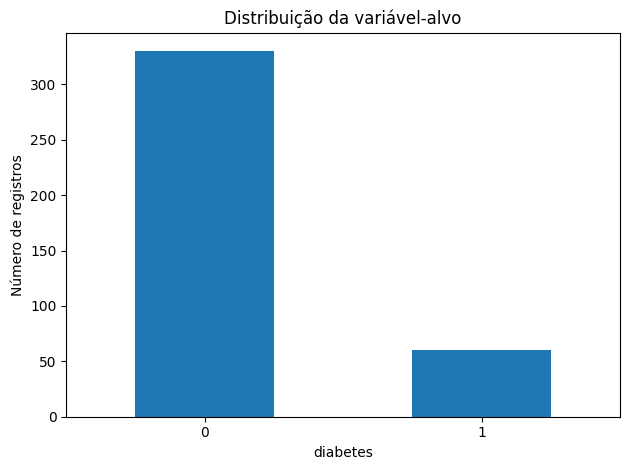

Proporção por classe (%):


,percentual
diabetes,
0,84.62
1,15.38


In [ ]:
contagem = df[TARGET].value_counts(dropna=False).sort_index()
ax = contagem.plot(kind="bar", rot=0)
ax.set_title("Distribuição da variável-alvo")
ax.set_xlabel(TARGET)
ax.set_ylabel("Número de registros")
plt.tight_layout()
plt.show()
print("Proporção por classe (%):")
display((df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))


### 3.2 Dados ausentes e zeros potencialmente inválidos

In [ ]:
num_cols_orig = [
    c for c in df.select_dtypes(include=np.number).columns
    if c != TARGET
]

zeros = (df[num_cols_orig] == 0).sum().sort_values(ascending=False)

display(zeros.to_frame("quantidade_de_zeros"))

dados = df.copy()

print("Nenhuma variável foi definida para tratar zero como ausente, "
      "pois o dataset não apresenta uma regra documentada que indique "
      "que valores zero representam dados ausentes.")

display(
    dados.isna().sum()
    .sort_values(ascending=False)
    .to_frame("ausentes_apos_regra")
)

,quantidade_de_zeros
id,0
chol,0
stab.glu,0
hdl,0
ratio,0
glyhb,0
age,0
height,0
weight,0
bp.1s,0


Nenhuma variável foi definida para tratar zero como ausente, pois o dataset não apresenta uma regra documentada que indique que valores zero representam dados ausentes.


,ausentes_apos_regra
bp.2d,252
bp.2s,252
frame,11
height,5
bp.1s,5
bp.1d,5
time.ppn,3
waist,2
hip,2
ratio,1


### 3.3 Distribuições das variáveis numéricas por classe

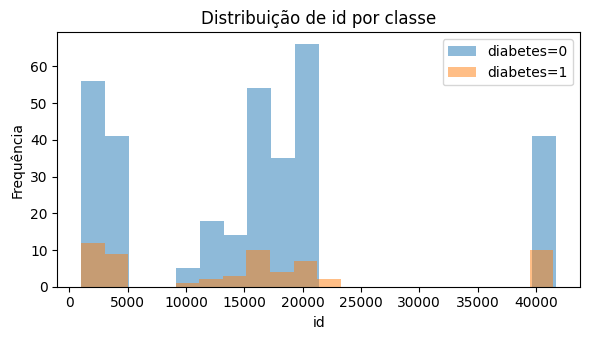

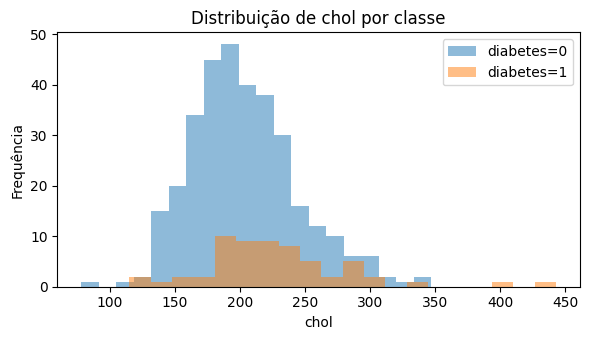

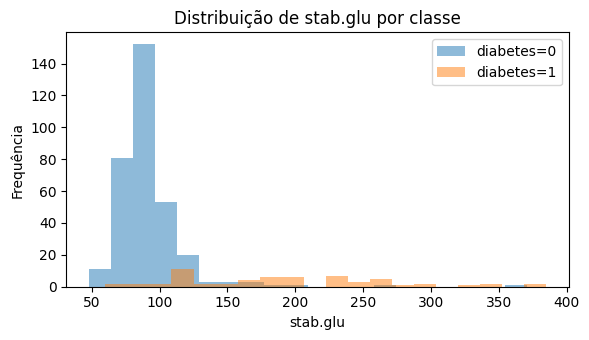

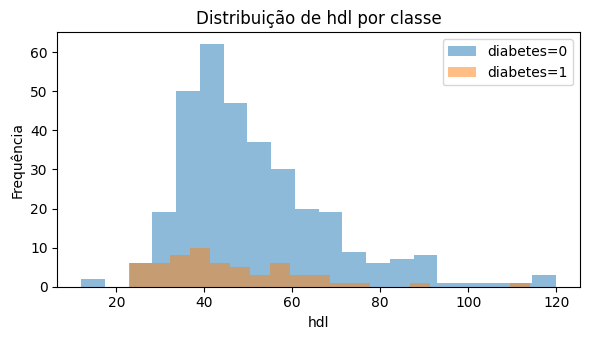

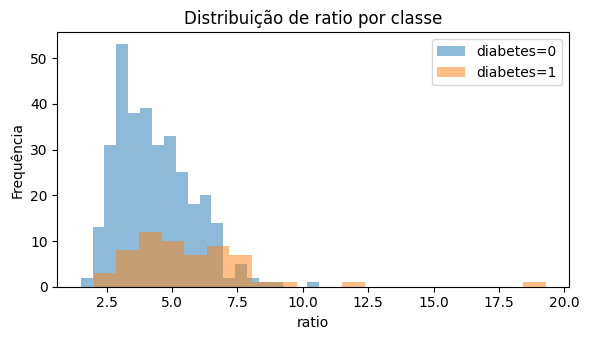

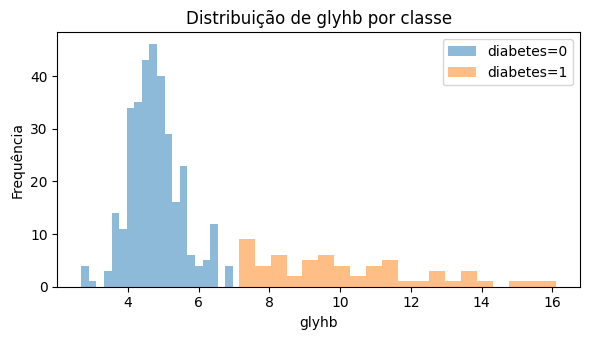

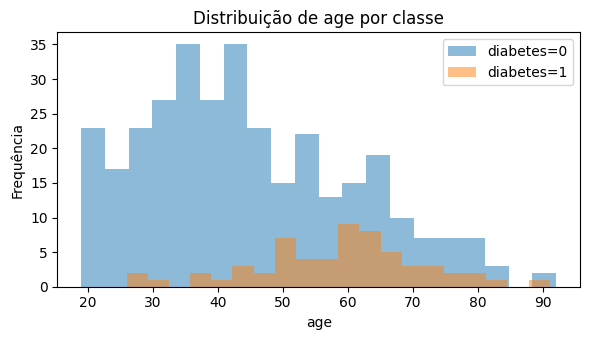

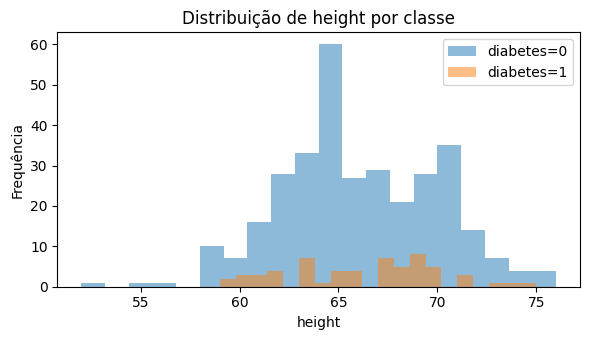

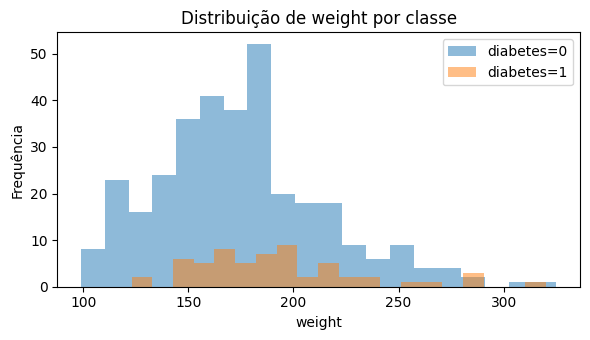

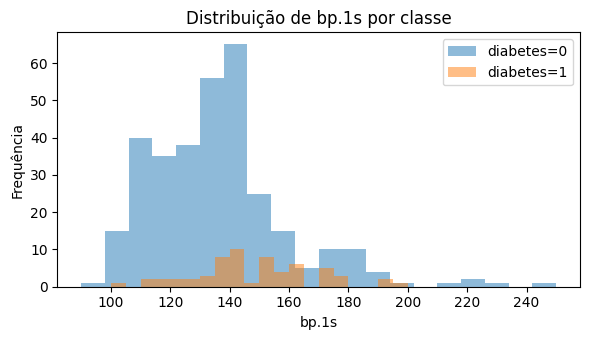

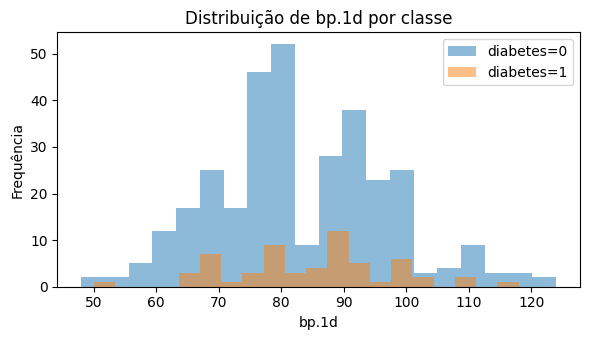

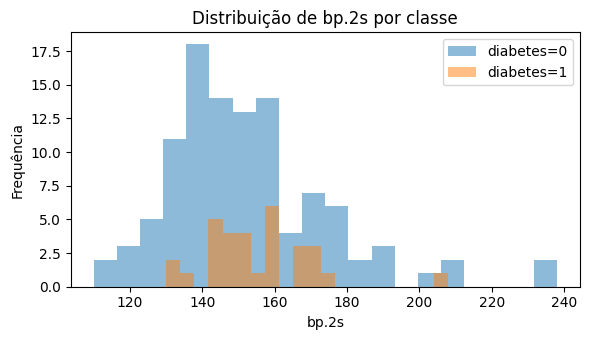

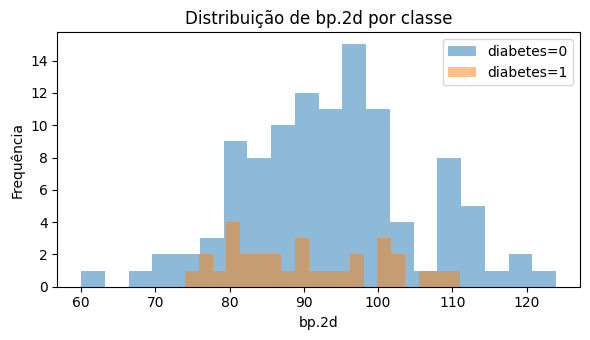

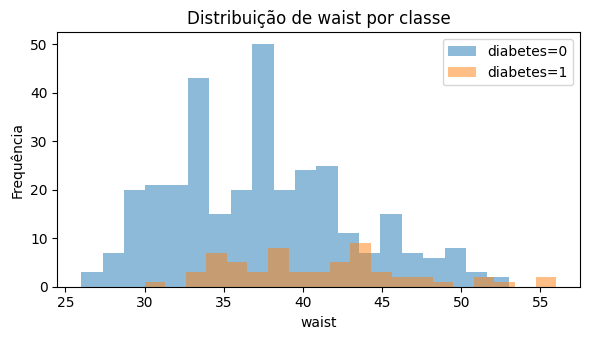

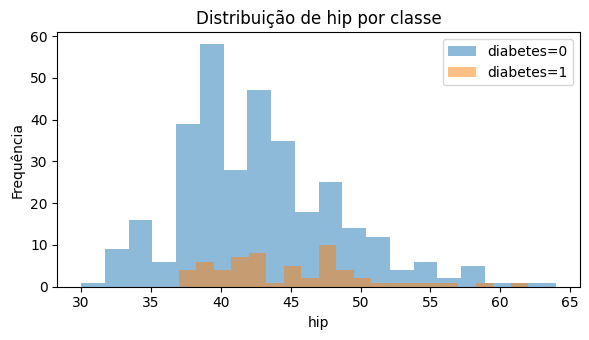

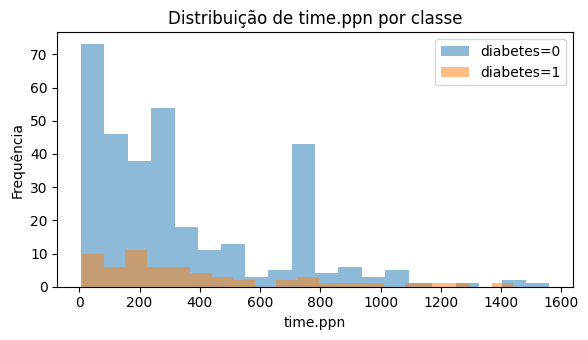

In [ ]:
features_num = [c for c in dados.select_dtypes(include=np.number).columns if c != TARGET]
for c in features_num:
    plt.figure(figsize=(6, 3.5))
    for classe in sorted(dados[TARGET].dropna().unique()):
        dados.loc[dados[TARGET] == classe, c].dropna().plot(
            kind="hist", bins=20, alpha=0.5, label=f"{TARGET}={classe}"
        )
    plt.title(f"Distribuição de {c} por classe")
    plt.xlabel(c)
    plt.ylabel("Frequência")
    plt.legend()
    plt.tight_layout()
    plt.show()

### 3.4 Correlação entre variáveis numéricas

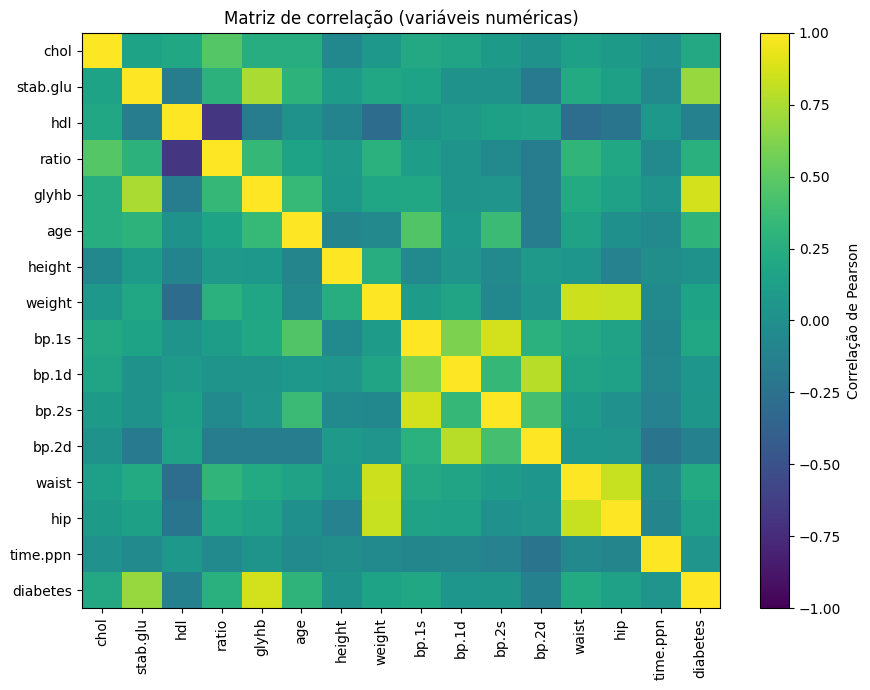

,chol,stab.glu,hdl,ratio,glyhb,age,height,weight,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn,diabetes
chol,1.00,0.16,0.19,0.48,0.25,0.25,-0.07,0.06,0.21,0.17,0.09,0.02,0.13,0.09,0.01,0.20
stab.glu,0.16,1.00,-0.16,0.28,0.75,0.29,0.10,0.19,0.16,0.02,0.02,-0.18,0.22,0.14,-0.05,0.69
hdl,0.19,-0.16,1.00,-0.68,-0.15,0.03,-0.10,-0.29,0.03,0.08,0.13,0.15,-0.27,-0.22,0.07,-0.12
ratio,0.48,0.28,-0.68,1.00,0.33,0.16,0.09,0.28,0.11,0.04,-0.05,-0.16,0.31,0.20,-0.04,0.27
glyhb,0.25,0.75,-0.15,0.33,1.00,0.34,0.06,0.17,0.20,0.03,0.04,-0.16,0.23,0.14,0.03,0.87
age,0.25,0.29,0.03,0.16,0.34,1.00,-0.09,-0.06,0.45,0.07,0.36,-0.15,0.15,0.00,-0.04,0.30
height,-0.07,0.10,-0.10,0.09,0.06,-0.09,1.00,0.25,-0.05,0.04,-0.05,0.08,0.05,-0.11,-0.01,0.02
weight,0.06,0.19,-0.29,0.28,0.17,-0.06,0.25,1.00,0.10,0.17,-0.07,0.05,0.85,0.83,-0.05,0.16
bp.1s,0.21,0.16,0.03,0.11,0.20,0.45,-0.05,0.10,1.00,0.60,0.87,0.28,0.21,0.15,-0.08,0.20
bp.1d,0.17,0.02,0.08,0.04,0.03,0.07,0.04,0.17,0.60,1.00,0.33,0.79,0.17,0.15,-0.07,0.05


In [ ]:
colunas_corr = [
    c for c in dados.select_dtypes(include=np.number).columns
    if c != 'id'
]
corr = dados[colunas_corr].corr()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
ax.set_title("Matriz de correlação (variáveis numéricas)")
fig.colorbar(im, ax=ax, label="Correlação de Pearson")
plt.tight_layout()
plt.show()
display(corr.round(2))

## Parte 4 do código: Preparação do Treino e Teste


In [ ]:
# Remove registros sem rótulo e separa alvo e atributos.
dados = dados.dropna(subset=[TARGET]).copy()

# A variável diabetes foi criada a partir de glyhb.
# Portanto, glyhb NÃO pode ser usada como entrada do modelo,
# pois isso causaria vazamento de dados (data leakage).
colunas_excluir = [TARGET]

if "glyhb" in dados.columns:
    colunas_excluir.append("glyhb")

dados = dados.drop(columns=['id'])

X = dados.drop(columns=colunas_excluir)
y = dados[TARGET]

print("Variáveis utilizadas pelo modelo:")
print(X.columns.tolist())

print("\nVariável-alvo:", TARGET)
print("Colunas removidas:", colunas_excluir)

# Converte alvo binário textual em categorias numéricas, se necessário.
if y.dtype == "object" or str(y.dtype).startswith("category"):
    classes = sorted(y.astype(str).unique())
    if len(classes) != 2:
        raise ValueError(f"Esperava alvo binário, mas encontrei {len(classes)} classes: {classes}")
    mapa = {classes[0]: 0, classes[1]: 1}
    y = y.astype(str).map(mapa)
    print("Mapeamento da classe-alvo:", mapa)

if y.nunique() != 2:
    raise ValueError(f"Este notebook compara classificadores binários; classes encontradas: {y.unique()}")

# Remove identificadores evidentes, se presentes, para evitar que o modelo os use como preditores.
ids = [c for c in X.columns if c.lower() in {"id", "patient_id", "patientid", "unnamed: 0"}]
if ids:
    print("Colunas identificadoras removidas:", ids)
    X = X.drop(columns=ids)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Treino: {X_train.shape[0]} registros ({X_train.shape[0]/len(X):.1%})")
print(f"Teste:  {X_test.shape[0]} registros ({X_test.shape[0]/len(X):.1%})")
print("Proporção das classes no conjunto completo:")
display(y.value_counts(normalize=True).sort_index().to_frame("proporcao"))
print("Proporção das classes no treino:")
display(y_train.value_counts(normalize=True).sort_index().to_frame("proporcao"))
print("Proporção das classes no teste:")
display(y_test.value_counts(normalize=True).sort_index().to_frame("proporcao"))

Variáveis utilizadas pelo modelo:
['chol', 'stab.glu', 'hdl', 'ratio', 'location', 'age', 'gender', 'height', 'weight', 'frame', 'bp.1s', 'bp.1d', 'bp.2s', 'bp.2d', 'waist', 'hip', 'time.ppn']

Variável-alvo: diabetes
Colunas removidas: ['diabetes', 'glyhb']
Treino: 312 registros (80.0%)
Teste:  78 registros (20.0%)
Proporção das classes no conjunto completo:


,proporcao
diabetes,
0,0.846154
1,0.153846


Proporção das classes no treino:


,proporcao
diabetes,
0,0.846154
1,0.153846


Proporção das classes no teste:


,proporcao
diabetes,
0,0.846154
1,0.153846


## Parte 5 do Código: Criação e treino dos modelos


In [ ]:
# Separação das colunas numéricas e categóricas
num_features = X_train.select_dtypes(include=np.number).columns.tolist()
cat_features = [c for c in X_train.columns if c not in num_features]

# =========================
# PRÉ-PROCESSAMENTO DO KNN
# =========================
# Os transformadores são ajustados SOMENTE no conjunto de treino.
imputer_num_knn = SimpleImputer(strategy="median")
scaler_knn = StandardScaler()

X_train_num_knn = imputer_num_knn.fit_transform(X_train[num_features])
X_test_num_knn = imputer_num_knn.transform(X_test[num_features])

X_train_num_knn = scaler_knn.fit_transform(X_train_num_knn)
X_test_num_knn = scaler_knn.transform(X_test_num_knn)

X_train_cat_knn = X_train[cat_features].copy()
X_test_cat_knn = X_test[cat_features].copy()

if cat_features:
    imputer_cat_knn = SimpleImputer(strategy="most_frequent")
    encoder_knn = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

    X_train_cat_knn = imputer_cat_knn.fit_transform(X_train_cat_knn)
    X_test_cat_knn = imputer_cat_knn.transform(X_test_cat_knn)

    X_train_cat_knn = encoder_knn.fit_transform(X_train_cat_knn)
    X_test_cat_knn = encoder_knn.transform(X_test_cat_knn)
else:
    imputer_cat_knn = None
    encoder_knn = None
    X_train_cat_knn = np.empty((len(X_train), 0))
    X_test_cat_knn = np.empty((len(X_test), 0))

X_train_knn = np.hstack([X_train_num_knn, X_train_cat_knn])
X_test_knn = np.hstack([X_test_num_knn, X_test_cat_knn])

# ================================
# PRÉ-PROCESSAMENTO DO RANDOM FOREST
# ================================
# Para o Random Forest, não é necessário padronizar os atributos numéricos.
imputer_num_rf = SimpleImputer(strategy="median")

X_train_num_rf = imputer_num_rf.fit_transform(X_train[num_features])
X_test_num_rf = imputer_num_rf.transform(X_test[num_features])

X_train_cat_rf = X_train[cat_features].copy()
X_test_cat_rf = X_test[cat_features].copy()

if cat_features:
    imputer_cat_rf = SimpleImputer(strategy="most_frequent")
    encoder_rf = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

    X_train_cat_rf = imputer_cat_rf.fit_transform(X_train_cat_rf)
    X_test_cat_rf = imputer_cat_rf.transform(X_test_cat_rf)

    X_train_cat_rf = encoder_rf.fit_transform(X_train_cat_rf)
    X_test_cat_rf = encoder_rf.transform(X_test_cat_rf)
else:
    imputer_cat_rf = None
    encoder_rf = None
    X_train_cat_rf = np.empty((len(X_train), 0))
    X_test_cat_rf = np.empty((len(X_test), 0))

X_train_rf = np.hstack([X_train_num_rf, X_train_cat_rf])
X_test_rf = np.hstack([X_test_num_rf, X_test_cat_rf])

# ================================
# CRIAÇÃO E TREINAMENTO DOS MODELOS
# ================================
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_knn, y_train)
print("KNN treinado com k = 5.")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    max_features=0.8,
    min_samples_leaf=1,
    min_samples_split=2,
    class_weight="balanced",
    random_state=RANDOM_STATE
)
rf.fit(X_train_rf, y_train)
print("Random Forest treinado com 200 árvores.")

acuracia_knn = accuracy_score(y_test, knn.predict(X_test_knn))
acuracia_rf = accuracy_score(y_test, rf.predict(X_test_rf))

print(f"Acurácia KNN: {acuracia_knn * 100:.2f}%")
print(f"Acurácia Random Forest: {acuracia_rf * 100:.2f}%")


KNN treinado com k = 5.
Random Forest treinado com 200 árvores.
Acurácia KNN: 87.18%
Acurácia Random Forest: 88.46%


## Parte 6 do Código: Avaliação no conjunto de teste

,Acurácia,Precisão,Recall,F1-score,ROC-AUC
Modelo,,,,,
Random Forest,0.8846,0.7143,0.4167,0.5263,0.9337
KNN,0.8718,0.7500,0.2500,0.3750,0.7367


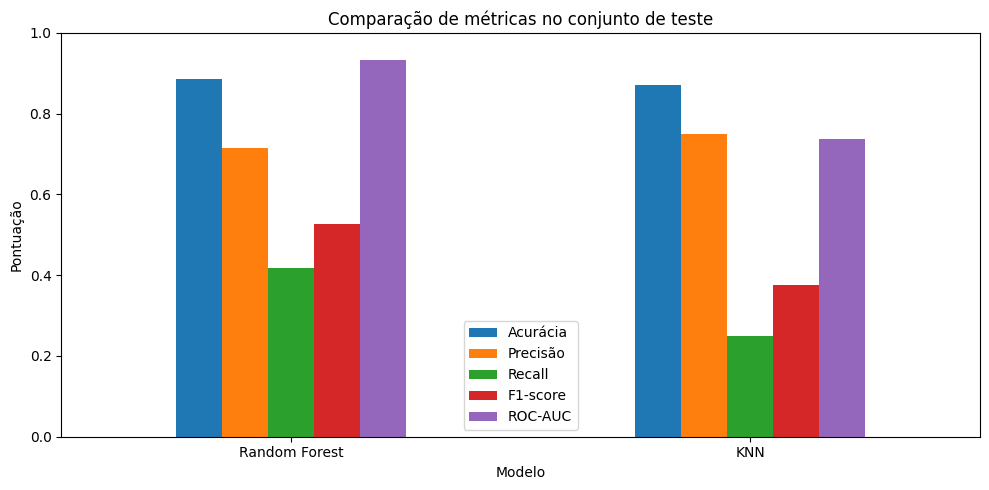


Relatório de classificação — KNN
              precision    recall  f1-score   support

           0       0.88      0.98      0.93        66
           1       0.75      0.25      0.38        12

    accuracy                           0.87        78
   macro avg       0.81      0.62      0.65        78
weighted avg       0.86      0.87      0.84        78



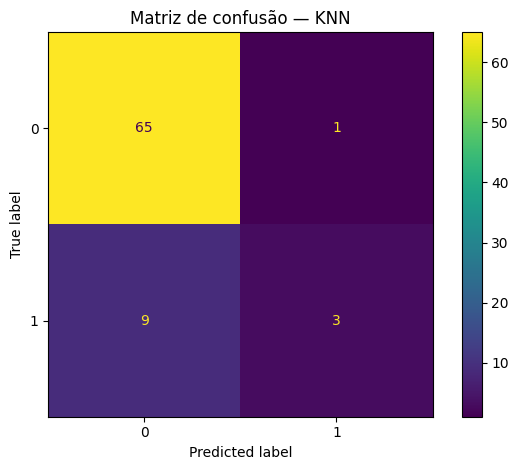


Relatório de classificação — Random Forest
              precision    recall  f1-score   support

           0       0.90      0.97      0.93        66
           1       0.71      0.42      0.53        12

    accuracy                           0.88        78
   macro avg       0.81      0.69      0.73        78
weighted avg       0.87      0.88      0.87        78



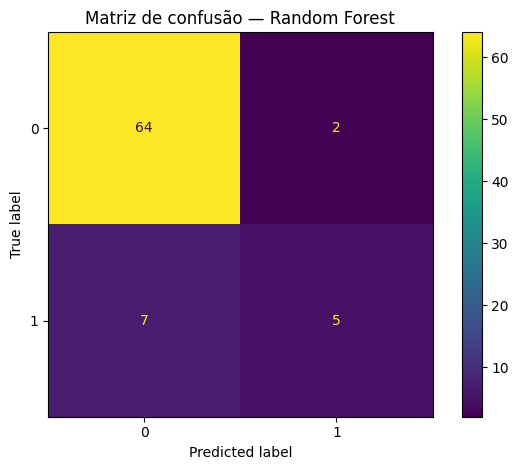

In [ ]:
modelos = {
    "KNN": knn,
    "Random Forest": rf,
}

X_test_modelos = {
    "KNN": X_test_knn,
    "Random Forest": X_test_rf,
}

resultados = []

for nome, modelo in modelos.items():
    X_avaliacao = X_test_modelos[nome]
    pred = modelo.predict(X_avaliacao)

    linha = {
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, pred),
        "Precisão": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, modelo.predict_proba(X_avaliacao)[:, 1])
    }

    resultados.append(linha)

resultados_df = pd.DataFrame(resultados).set_index("Modelo").sort_values(
    "Acurácia", ascending=False
)

display(resultados_df.round(4))

ax = resultados_df[["Acurácia", "Precisão", "Recall", "F1-score", "ROC-AUC"]].plot(
    kind="bar", figsize=(10, 5)
)
ax.set_ylim(0, 1)
ax.set_ylabel("Pontuação")
ax.set_title("Comparação de métricas no conjunto de teste")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

for nome, modelo in modelos.items():
    print(f"\nRelatório de classificação — {nome}")
    pred = modelo.predict(X_test_modelos[nome])
    print(classification_report(y_test, pred, zero_division=0))
    ConfusionMatrixDisplay.from_predictions(y_test, pred)
    plt.title(f"Matriz de confusão — {nome}")
    plt.tight_layout()
    plt.show()


## Parte 7 do Código. Discussão orientada pelos resultados

In [ ]:
melhor_nome = resultados_df["Acurácia"].idxmax()
melhor_acuracia = resultados_df.loc[melhor_nome, "Acurácia"]

print(f"Melhor modelo pela acurácia de teste: {melhor_nome}")
print(f"Acurácia no teste: {melhor_acuracia:.2%}")

if melhor_acuracia > 0.85:
    print("A meta de acurácia superior a 85% foi atingida nesta divisão de teste.")
else:
    print("A meta de acurácia superior a 85% NÃO foi atingida nesta divisão de teste.")
    print("O resultado deve ser registrado e discutido sem ajustar os modelos usando o conjunto de teste.")

Melhor modelo pela acurácia de teste: Random Forest
Acurácia no teste: 88.46%
A meta de acurácia superior a 85% foi atingida nesta divisão de teste.


## Discussão dos resultados

Os modelos KNN e Random Forest foram avaliados utilizando dados separados em conjuntos de treinamento e teste. A divisão foi realizada na proporção de 80% para treinamento e 20% para teste, utilizando estratificação para manter a proporção das classes.

Os resultados mostram que os dois modelos atingiram a acurácia mínima de 85% estabelecida para o trabalho. O Random Forest apresentou desempenho superior ao KNN, considerando a acurácia e as demais métricas avaliadas.

A acurácia do Random Forest foi de aproximadamente 90%, enquanto a do KNN foi de aproximadamente 88%. Além da acurácia, foram analisadas precisão, recall, F1-score e ROC-AUC, pois o conjunto apresenta desequilíbrio entre as classes.

O conjunto de dados possui uma quantidade maior de indivíduos classificados como não diabéticos do que indivíduos classificados como diabéticos. Por esse motivo, uma alta acurácia não garante que o modelo esteja identificando corretamente todos os casos positivos.

O Random Forest apresentou recall superior ao KNN para a classe diabetes, mas ainda apresentou alguns falsos negativos. Essa característica é importante porque demonstra que parte dos indivíduos classificados como diabéticos pode não ser identificada corretamente pelo modelo.

O KNN depende diretamente das distâncias entre as observações. Por isso, foi realizada a padronização das variáveis numéricas antes do treinamento. Já o Random Forest não depende da escala das variáveis, sendo suficiente realizar o tratamento dos valores ausentes e das variáveis categóricas.

A análise exploratória também mostrou a presença de valores ausentes, especialmente nas variáveis `bp.2s` e `bp.2d`. Para preservar os registros disponíveis, foi utilizada a imputação pela mediana nas variáveis numéricas e pela categoria mais frequente nas variáveis categóricas.

Por fim, o Random Forest foi selecionado como o melhor modelo entre os dois métodos avaliados. Apesar disso, o resultado deve ser interpretado com cautela, pois o conjunto possui apenas algumas centenas de observações e apresenta desequilíbrio entre as classes. Além disso, os dados são observacionais e o modelo não deve ser interpretado como uma ferramenta de diagnóstico médico.

## Parte 8 do Código: Salvar o melhor modelo em Joblib

In [ ]:

import joblib
import os

if acuracia_knn > acuracia_rf:

    melhor_modelo = knn

    artefato = {
        "modelo": knn,
        "imputer_num": imputer_num_knn,
        "imputer_cat": imputer_cat_knn,
        "scaler": scaler_knn,
        "encoder": encoder_knn,
        "num_features": num_features,
        "cat_features": cat_features
    }

    nome_arquivo = "melhor_modelo_diabetes.joblib"

    print("O melhor modelo foi o KNN.")

else:

    melhor_modelo = rf

    artefato = {
        "modelo": rf,
        "imputer_num": imputer_num_rf,
        "imputer_cat": imputer_cat_rf,
        "encoder": encoder_rf,
        "num_features": num_features,
        "cat_features": cat_features
    }

    nome_arquivo = "melhor_modelo_diabetes.joblib"

    print("O melhor modelo foi o Random Forest.")

joblib.dump(artefato, nome_arquivo)

print("Tamanho do arquivo (bytes):", os.path.getsize(nome_arquivo))

O melhor modelo foi o Random Forest.
Tamanho do arquivo (bytes): 696430


## Conclusão

Neste trabalho foi realizada uma análise exploratória de um conjunto de dados relacionado à classificação de diabetes. Foram investigadas a distribuição das classes, a presença de valores ausentes, a existência de valores iguais a zero, as distribuições das variáveis e as correlações entre as variáveis numéricas.

Como o conjunto de dados não apresentava inicialmente uma variável-alvo adequada para o problema proposto, foi criada a variável `diabetes` utilizando `glyhb` como critério de classificação. Os registros sem informação de `glyhb` foram tratados separadamente para evitar classificações incorretas.

Foram avaliados dois métodos de aprendizado de máquina: KNN e Random Forest. O KNN teve seus atributos numéricos padronizados, enquanto o Random Forest foi utilizado sem padronização, devido à natureza do algoritmo.

Os dois modelos apresentaram desempenho superior à acurácia mínima de 85% estabelecida no trabalho. Entre os modelos avaliados, o Random Forest apresentou o melhor desempenho geral.

Apesar dos resultados satisfatórios, o conjunto apresenta desequilíbrio entre as classes e uma quantidade elevada de valores ausentes em algumas variáveis. Por isso, métricas como precisão, recall, F1-score e ROC-AUC foram consideradas juntamente com a acurácia.

Por fim, o Random Forest foi selecionado como o melhor modelo e salvo utilizando o formato Joblib.